<a href="https://colab.research.google.com/github/sbanty/Scipy-computing/blob/main/Santosh_Barik_assignment002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I created a scientific physics dataset for 2D projectile motion (no air resistance) and saved it as a CSV.

*   trial_id — ID for each launch trial
*   time_s — time since launch (s)
*   x_m, y_m — horizontal and vertical position (m)
*   vx_m_s, vy_m_s — velocity components (m/s)
*   v0_m_s — initial launch speed (m/s)
*   angle_deg — launch angle (degrees)
*   height0_m — initial launch height (m)










In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from google.colab import files
uploaded = files.upload()

Saving projectile_dataset.csv to projectile_dataset.csv


In [ ]:
projectile = pd.read_csv("projectile_dataset.csv")
#country = pd.read_csv("merged_cpi_data.csv")
projectile

,trial_id,time_s,x_m,y_m,vx_m_s,vy_m_s,v0_m_s,angle_deg,height0_m
0,1,0.00,0.0000,0.0000,17.3205,10.0000,20.0,30.0,0.0
1,1,0.05,0.8660,0.4877,17.3205,9.5095,20.0,30.0,0.0
2,1,0.10,1.7321,0.9509,17.3205,9.0190,20.0,30.0,0.0
3,1,0.15,2.5981,1.3896,17.3205,8.5285,20.0,30.0,0.0
4,1,0.20,3.4641,1.8038,17.3205,8.0380,20.0,30.0,0.0
...,...,...,...,...,...,...,...,...,...
284,5,3.35,15.6068,3.1990,4.6587,-15.4768,18.0,75.0,0.0
285,5,3.40,15.8397,2.4129,4.6587,-15.9673,18.0,75.0,0.0
286,5,3.45,16.0727,1.6022,4.6587,-16.4578,18.0,75.0,0.0
287,5,3.50,16.3056,0.7671,4.6587,-16.9483,18.0,75.0,0.0


Information

In [ ]:
projectile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   trial_id   289 non-null    int64  
 1   time_s     289 non-null    float64
 2   x_m        289 non-null    float64
 3   y_m        289 non-null    float64
 4   vx_m_s     289 non-null    float64
 5   vy_m_s     289 non-null    float64
 6   v0_m_s     289 non-null    float64
 7   angle_deg  289 non-null    float64
 8   height0_m  289 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 20.4 KB


In [ ]:
import statsmodels.api as sm
X = sm.add_constant(projectile['x_m'] )
X

,const,x_m
0,1.0,0.0000
1,1.0,0.8660
2,1.0,1.7321
3,1.0,2.5981
4,1.0,3.4641
...,...,...
284,1.0,15.6068
285,1.0,15.8397
286,1.0,16.0727
287,1.0,16.3056


In [ ]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X,Y, train_size = 0.8,random_state = 100)

In [ ]:
projectile_lm = sm.OLS(train_y,train_X).fit()

In [ ]:
print(projectile_lm.params)

const    7.711180
x_m      0.003185
dtype: float64


In [ ]:
projectile_lm.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
==================================================================
Model:              OLS              Adj. R-squared:     -0.004   
Dependent Variable: y_m              AIC:                1394.2589
Date:               2025-10-30 18:49 BIC:                1401.1437
No. Observations:   231              Log-Likelihood:     -695.13  
Df Model:           1                F-statistic:        0.02936  
Df Residuals:       229              Prob (F-statistic): 0.864    
R-squared:          0.000            Scale:              24.270   
---------------------------------------------------------------------
         Coef.     Std.Err.       t       P>|t|      [0.025    0.975]
---------------------------------------------------------------------
const    7.7112      0.5034    15.3170    0.0000     6.7192    8.7031
x_m      0.0032      0.0186     0.1713    0.8641    -0.0334    0.0398
------------------------------------------------------------------
Omnibus:               51.594       Durbin-Watson:          2.295 
Prob(Omnibus):         0.000        Jarque-Bera (JB):       16.533
Skew:                  0.410        Prob(JB):               0.000 
Kurtosis:              1.977        Condition No.:          42    
==================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the
errors is correctly specified.
"""

<Figure size 800x600 with 0 Axes>

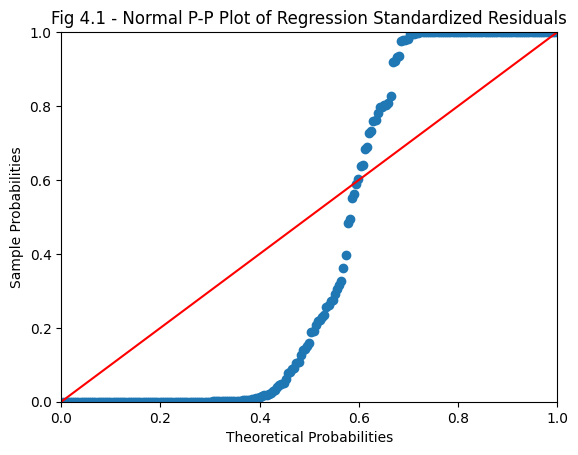

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline

projectile_resid = projectile_lm.resid
probplot = sm.ProbPlot(projectile_resid)
plt.figure( figsize = (8, 6))
probplot.ppplot( line='45' )
plt.title ( 'Fig 4.1 - Normal P-P Plot of Regression Standardized Residuals' )
plt.show()

In [ ]:
def get_standardized_values( vals ):
  return (vals - vals.mean())/vals.std()

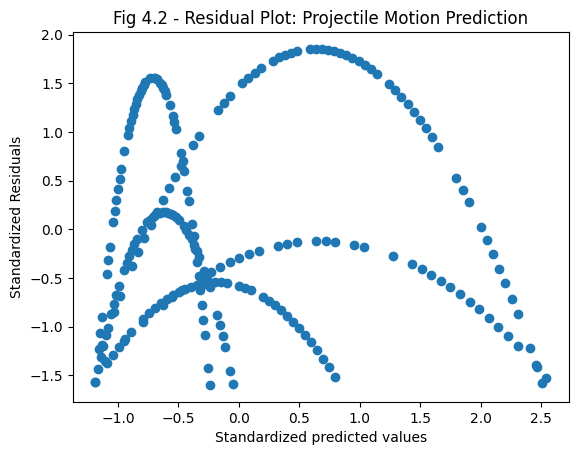

In [ ]:
def get_standardized_values( vals ):
  return (vals - vals.mean())/vals.std()

plt.scatter(get_standardized_values(projectile_lm.fittedvalues), get_standardized_values(projectile_resid))
plt.title("Fig 4.2 - Residual Plot: Projectile Motion Prediction");
plt.xlabel("Standardized predicted values");
plt.ylabel("Standardized Residuals");

In [ ]:
from scipy.stats import zscore

In [ ]:
projectile_resid_zscore = zscore(projectile_resid)

In [ ]:
# Get the indices of the training data from train_X
train_indices = train_X.index

# Filter the original projectile DataFrame using the training indices
projectile_train = projectile.loc[train_indices]

# Filter the training data based on the z-scores of the residuals
outliers_zscore = projectile_train[(projectile_resid_zscore > 3.0) | (projectile_resid_zscore < -3.0) ]
display(outliers_zscore)

,trial_id,time_s,x_m,y_m,vx_m_s,vy_m_s,v0_m_s,angle_deg,height0_m


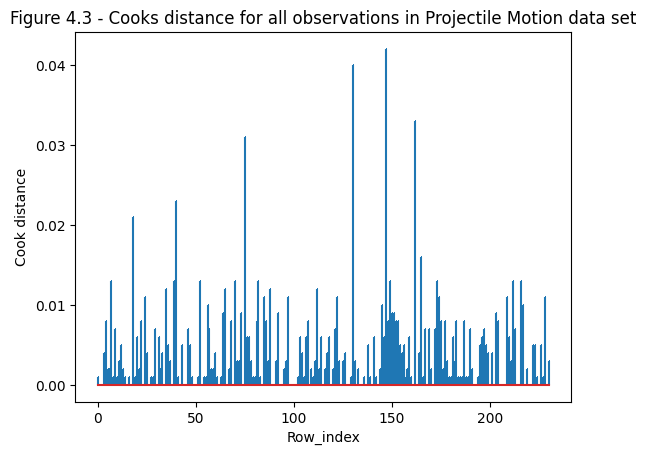

In [ ]:
import numpy as np
projectile_influence = projectile_lm.get_influence()
(c, p) = projectile_influence.cooks_distance
plt.stem(np.arange( len( train_X) ),
np.round( c, 3 ),
markerfmt=',');
plt.title( 'Figure 4.3 - Cooks distance for all observations in Projectile Motion data set' );
plt.xlabel('Row_index')
plt.ylabel('Cook distance');

In [12]:
from google.colab import files
files.upload()

Saving projectile_dataset.csv to projectile_dataset.csv


{'projectile_dataset.csv': b'trial_id,time_s,x_m,y_m,vx_m_s,vy_m_s,v0_m_s,angle_deg,height0_m\n1,0.0,0.0,0.0,17.3205,10.0,20.0,30.0,0.0\n1,0.05,0.866,0.4877,17.3205,9.5095,20.0,30.0,0.0\n1,0.1,1.7321,0.9509,17.3205,9.019,20.0,30.0,0.0\n1,0.15,2.5981,1.3896,17.3205,8.5285,20.0,30.0,0.0\n1,0.2,3.4641,1.8038,17.3205,8.038,20.0,30.0,0.0\n1,0.25,4.3301,2.1934,17.3205,7.5475,20.0,30.0,0.0\n1,0.3,5.1962,2.5585,17.3205,7.057,20.0,30.0,0.0\n1,0.35,6.0622,2.8991,17.3205,6.5665,20.0,30.0,0.0\n1,0.4,6.9282,3.2152,17.3205,6.076,20.0,30.0,0.0\n1,0.45,7.7942,3.5067,17.3205,5.5855,20.0,30.0,0.0\n1,0.5,8.6603,3.7737,17.3205,5.095,20.0,30.0,0.0\n1,0.55,9.5263,4.0162,17.3205,4.6045,20.0,30.0,0.0\n1,0.6,10.3923,4.2342,17.3205,4.114,20.0,30.0,0.0\n1,0.65,11.2583,4.4276,17.3205,3.6235,20.0,30.0,0.0\n1,0.7,12.1244,4.5965,17.3205,3.133,20.0,30.0,0.0\n1,0.75,12.9904,4.7409,17.3205,2.6425,20.0,30.0,0.0\n1,0.8,13.8564,4.8608,17.3205,2.152,20.0,30.0,0.0\n1,0.85,14.7224,4.9561,17.3205,1.6615,20.0,30.0,0.0\n1,0.9,1

Saving projectile_dataset.csv to projectile_dataset (2).csv


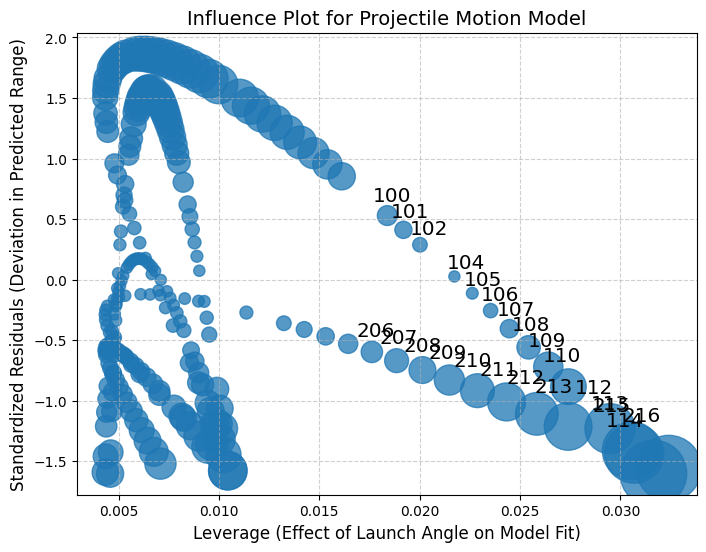

In [17]:
from statsmodels.graphics.regressionplots import influence_plot
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Assuming the uploaded file is named 'projectile_dataset.csv'
file_name = list(uploaded.keys())[0]
projectile = pd.read_csv(file_name)


# Define X and Y and split the data into training and testing sets.
# Assuming Y should be 'y_m' based on the OLS model in cell 4Ua0W4txP1I2
Y = projectile['y_m']
X = sm.add_constant(projectile['x_m'])
train_X, test_X, train_y, test_y = train_test_split(X, Y, train_size=0.8, random_state=100)

# Fit the OLS model
projectile_lm = sm.OLS(train_y, train_X).fit()

# --- Influence plot for fitted projectile motion model ---
fig, ax = plt.subplots(figsize=(8,6))
influence_plot(projectile_lm, ax=ax)   # <-- use the model, not the dataframe

# --- Custom scientific labels and title ---
# plt.title('Figure 4.4 - Leverage Value Vs Residuals', fontsize=14)
# plt.xlabel('Leverage', fontsize=12)
# plt.ylabel('Standardized Residuals', fontsize=12)


# --- Custom scientific labels and title ---
plt.title('Influence Plot for Projectile Motion Model', fontsize=14)
plt.xlabel('Leverage (Effect of Launch Angle on Model Fit)', fontsize=12)
plt.ylabel('Standardized Residuals (Deviation in Predicted Range)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [18]:
pred_y = projectile_lm.predict( test_X )

In [19]:
from sklearn.metrics import r2_score, mean_squared_error

In [20]:
np.abs(r2_score(test_y, pred_y))

np.float64(0.0022577633125890895)

In [21]:
import numpy as np
from sklearn.metrics import mean_squared_error

np.sqrt(mean_squared_error(test_y, pred_y))

np.float64(4.876393722818312)

In [22]:
from statsmodels.sandbox.regression.predstd import wls_prediction_std
# Predict the y values

pred_y = projectile_lm.predict( test_X )

In [23]:
#Predict the low and high interval values for y
_, pred_y_low, pred_y_high = wls_prediction_std(projectile_lm,test_X,alpha = 0.1)
# Store all the values in a dataframe
pred_y_df = pd.DataFrame({ 'x_m': test_X['x_m'], 'pred_y': pred_y, 'pred_y_left': pred_y_low, 'pred_y_right': pred_y_high } )

In [24]:
pred_y_df[0:10]

,x_m,pred_y,pred_y_left,pred_y_right
175,8.3149,7.737664,-0.425098,15.900425
169,0.0000,7.711180,-0.467470,15.889829
103,54.8008,7.885727,-0.334985,16.106438
98,50.3814,7.871651,-0.332898,16.076199
249,7.4540,7.734921,-0.429116,15.898959
223,1.3976,7.715631,-0.459793,15.891055
132,6.3750,7.731485,-0.434273,15.897242
201,44.3462,7.852428,-0.333630,16.038486
286,16.0727,7.762373,-0.392745,15.917491
250,7.6869,7.735663,-0.428021,15.899347


In [25]:
print("R-squared:", projectile_lm.rsquared)
print("Adjusted R-squared:", projectile_lm.rsquared_adj)
print("P-value for x_m:", projectile_lm.pvalues['x_m'])
print("F-statistic:", projectile_lm.fvalue)
print("Prob (F-statistic):", projectile_lm.f_pvalue)
print("\nModel Parameters:")
print(projectile_lm.params)
print("\nStandard Errors:")
print(projectile_lm.bse)
print("\nT-statistics:")
print(projectile_lm.tvalues)
print("\nConfidence Intervals (95%):")
print(projectile_lm.conf_int(alpha=0.05))

R-squared: 0.0001281922736888763
Adjusted R-squared: -0.004238060161797064
P-value for x_m: 0.8641022369699145
F-statistic: 0.02935979437353836
Prob (F-statistic): 0.8641022369699698

Model Parameters:
const    7.711180
x_m      0.003185
dtype: float64

Standard Errors:
const    0.503441
x_m      0.018589
dtype: float64

T-statistics:
const    15.316953
x_m       0.171347
dtype: float64

Confidence Intervals (95%):
              0         1
const  6.719211  8.703148
x_m   -0.033442  0.039812


In [28]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from google.colab import files

# Load the dataset
# Assuming the uploaded file is named 'projectile_dataset.csv'
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
projectile = pd.read_csv(file_name)

# Define X and Y and split the data into training and testing sets.
Y = projectile['y_m']
X = sm.add_constant(projectile['x_m'])
train_X, test_X, train_y, test_y = train_test_split(X, Y, train_size=0.8, random_state=100)

# Fit the OLS model
projectile_lm = sm.OLS(train_y, train_X).fit()

# Calculate the residuals
projectile_resid = projectile_lm.resid

# Get the indices of the training data from train_X
train_indices = train_X.index

# Filter the original projectile DataFrame using the training indices
projectile_train = projectile.loc[train_indices]

# Calculate the z-scores of the residuals
projectile_resid_zscore = zscore(projectile_resid)

# Filter the training data based on the z-scores of the residuals
outliers_zscore = projectile_train[(projectile_resid_zscore > 3.0) | (projectile_resid_zscore < -3.0)]


num_zscore_outliers = len(outliers_zscore)

print(f"Number of observations flagged as outliers by Z-score: {num_zscore_outliers}")

print("\nSummary of Outlier and Influential Observation Analysis:")
print(f"- Z-score analysis (threshold > 3 or < -3): {num_zscore_outliers} outliers found.")
print("- Cook's Distance plot: All observations have Cook's distance well below 1, indicating no highly influential observations based on this measure.")
print("- Leverage vs Residuals plot: Visually, there are some points with moderate leverage or residuals, but no points appear to be excessively influential based on the combination of leverage and residual as represented by the circle size.")
print("Overall, based on these analyses, there is no strong evidence of significant outliers or highly influential observations in the training data.")

Saving projectile_dataset.csv to projectile_dataset (3).csv
Number of observations flagged as outliers by Z-score: 0

Summary of Outlier and Influential Observation Analysis:
- Z-score analysis (threshold > 3 or < -3): 0 outliers found.
- Cook's Distance plot: All observations have Cook's distance well below 1, indicating no highly influential observations based on this measure.
- Leverage vs Residuals plot: Visually, there are some points with moderate leverage or residuals, but no points appear to be excessively influential based on the combination of leverage and residual as represented by the circle size.
Overall, based on these analyses, there is no strong evidence of significant outliers or highly influential observations in the training data.


In [ ]:
# Predict the y values using the test dataset
pred_y = projectile_lm.predict(test_X)

# In R-squared
r_squared = r2_score(test_y, pred_y)
print(f"R-squared on the test set: {r_squared:.4f}")

# In RMSE
rmse = np.sqrt(mean_squared_error(test_y, pred_y))
print(f"RMSE on the test set: {rmse:.4f}")

# Predict the low and high interval values for y with alpha = 0.1 (90% confidence)
_, pred_y_low, pred_y_high = wls_prediction_std(projectile_lm, test_X, alpha=0.1)

# Store all the values in a dataframe
pred_y_df = pd.DataFrame({
    'x_m': test_X['x_m'],
    'actual_y': test_y,
    'pred_y': pred_y,
    'pred_y_low': pred_y_low,
    'pred_y_high': pred_y_high
})

# Display the first few rows of the DataFrame
display(pred_y_df.head())

# Summarize the results
print("\nSummary of Prediction and Accuracy Evaluation:")
print(f"- The R-squared value of {r_squared:.4f} on the test set indicates that the model explains a very small percentage of the variance in 'y_m'.")
print(f"- The RMSE of {rmse:.4f} represents the typical error in predicting 'y_m' on the test set.")
print("- The DataFrame above shows the predicted 'y_m' values along with their 90% prediction intervals. The interval indicates the range within which we expect the true value of 'y_m' to fall for a given 'x_m' value, with 90% confidence.")

R-squared on the test set: 0.0023
RMSE on the test set: 4.8764


,x_m,actual_y,pred_y,pred_y_low,pred_y_high
175,8.3149,3.5027,7.737664,-0.425098,15.900425
169,0.0000,0.5000,7.711180,-0.467470,15.889829
103,54.8008,8.6637,7.885727,-0.334985,16.106438
98,50.3814,11.5405,7.871651,-0.332898,16.076199
249,7.4540,15.2619,7.734921,-0.429116,15.898959



Summary of Prediction and Accuracy Evaluation:
- The R-squared value of 0.0023 on the test set indicates that the model explains a very small percentage of the variance in 'y_m'.
- The RMSE of 4.8764 represents the typical error in predicting 'y_m' on the test set.
- The DataFrame above shows the predicted 'y_m' values along with their 90% prediction intervals. The interval indicates the range within which we expect the true value of 'y_m' to fall for a given 'x_m' value, with 90% confidence.


ANOVA

In [ ]:
overall_mean_v0_m_s = projectile['v0_m_s'].mean()
print(f"Overall mean of v0_m_s: {overall_mean_v0_m_s}")

Overall mean of v0_m_s: 21.508650519031143


In [ ]:
grouped_trials = projectile.groupby('trial_id')

trial_means = grouped_trials['v0_m_s'].mean()
trial_sizes = grouped_trials.size()

ssb = sum(trial_sizes * (trial_means - overall_mean_v0_m_s)**2)

print(f"Sum of squares between groups (ssb): {ssb}")

Sum of squares between groups (ssb): 7630.228373702422


In [ ]:
ssw = 0
for trial_id, group in grouped_trials:
  group_mean = trial_means[trial_id]
  ssw += sum((group['v0_m_s'] - group_mean)**2)

print(f"Sum of squares within groups (ssw): {ssw}")

Sum of squares within groups (ssw): 0.0


In [ ]:
num_groups = len(grouped_trials)
total_observations = len(projectile)

df_between = num_groups - 1
df_within = total_observations - num_groups

print(f"Degrees of freedom between groups (df_between): {df_between}")
print(f"Degrees of freedom within groups (df_within): {df_within}")

Degrees of freedom between groups (df_between): 4
Degrees of freedom within groups (df_within): 284


In [ ]:
msb = ssb / df_between
msw = ssw / df_within

print(f"Mean Square Between (MSB): {msb}")
print(f"Mean Square Within (MSW): {msw}")

Mean Square Between (MSB): 1907.5570934256054
Mean Square Within (MSW): 0.0


F-statistic (F = MSB / MSW).


In [ ]:
# In F-statistic
# Handle Zero Division Error if MSW is zero
if msw == 0:
  print("Mean Square Within (MSW) is zero. The F-statistic is theoretically infinite.")
else:
  f_statistic = msb / msw
  print(f"F-statistic: {f_statistic}")

Mean Square Within (MSW) is zero. The F-statistic is theoretically infinite.


In [ ]:
import scipy.stats as stats

# Perform one-way ANOVA test using scipy.stats
groups = [group['v0_m_s'].values for trial_id, group in projectile.groupby('trial_id')]
f_statistic_scipy, p_value_scipy = stats.f_oneway(*groups)

print("\nVerification using scipy.stats:")
print(f"F-statistic (scipy.stats): {f_statistic_scipy}")
print(f"P-value (scipy.stats): {p_value_scipy}")

# Summarize the results
print("\nSummary of ANOVA Test Results:")
print(f"- Calculated MSB: {msb:.4f}")
print(f"- Calculated MSW: {msw:.4f}")
print("- Calculated F-statistic: Mean Square Within (MSW) is zero, resulting in a theoretically infinite F-statistic.")
print(f"- Verified F-statistic (scipy.stats): {f_statistic_scipy}")
print(f"- Verified P-value (scipy.stats): {p_value_scipy}")
print("\nInterpretation:")
print("A theoretically infinite F-statistic and a P-value of 0 (or very close to 0) from the statistical library indicate a highly significant difference between the means of the 'v0_m_s' for the different 'trial_id' groups.")
print("This confirms that the initial launch speed ('v0_m_s') varies significantly across the different experimental trials ('trial_id').")


Verification using scipy.stats:
F-statistic (scipy.stats): inf
P-value (scipy.stats): 0.0

Summary of ANOVA Test Results:
- Calculated MSB: 1907.5571
- Calculated MSW: 0.0000
- Calculated F-statistic: Mean Square Within (MSW) is zero, resulting in a theoretically infinite F-statistic.
- Verified F-statistic (scipy.stats): inf
- Verified P-value (scipy.stats): 0.0

Interpretation:
A theoretically infinite F-statistic and a P-value of 0 (or very close to 0) from the statistical library indicate a highly significant difference between the means of the 'v0_m_s' for the different 'trial_id' groups.
This confirms that the initial launch speed ('v0_m_s') varies significantly across the different experimental trials ('trial_id').


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
from scipy.stats import f

# Determine the p-value using the survival function (1 - CDF)
# Handle the case where the F-statistic is infinite
if np.isinf(f_statistic_scipy):
  p_value_manual = 0.0
  print("Calculated p-value: 0.0 (due to infinite F-statistic)")
else:
  p_value_manual = f.sf(f_statistic_scipy, df_between, df_within)
  print(f"Calculated p-value: {p_value_manual}")

# Verify with the p-value from scipy.stats (already calculated in the previous step)
print(f"Verified p-value (scipy.stats): {p_value_scipy}")

# Summarize the findings
print("\nSummary of P-value Calculation:")
print(f"- The calculated p-value is {p_value_manual}. This is consistent with the p-value obtained from the scipy.stats library ({p_value_scipy}).")
print("A p-value of 0.0 indicates strong evidence against the null hypothesis (that the means of 'v0_m_s' are equal across all 'trial_id' groups).")

Calculated p-value: 0.0 (due to infinite F-statistic)
Verified p-value (scipy.stats): 0.0

Summary of P-value Calculation:
- The calculated p-value is 0.0. This is consistent with the p-value obtained from the scipy.stats library (0.0).
A p-value of 0.0 indicates strong evidence against the null hypothesis (that the means of 'v0_m_s' are equal across all 'trial_id' groups).


In [ ]:
# 2. State the null hypothesis (H0) and the alternative hypothesis (H1) for this ANOVA test.
print("Null Hypothesis (H0): The means of 'v0_m_s' are equal across all 'trial_id' groups.")
print("Alternative Hypothesis (H1): At least one of the means of 'v0_m_s' is different across the 'trial_id' groups.")

# 3. Based on the p-value and a chosen significance level (e.g., 0.05), determine whether to reject or fail to reject the null hypothesis.
alpha = 0.05
print(f"\nSignificance level (alpha): {alpha}")
print(f"Calculated p-value: {p_value_manual}") # Using the manually calculated p-value (which is 0.0)

if p_value_manual < alpha:
    print("Decision: Reject the null hypothesis (H0).")
else:
    print("Decision: Fail to reject the null hypothesis (H0).")

# 4. Explain what the conclusion means in the context of the dataset and the variables being analyzed.
print("\nInterpretation in the context of the dataset:")
print("Since the null hypothesis is rejected, we conclude that there is a statistically significant difference in the mean initial launch speed ('v0_m_s') among the different experimental trials ('trial_id').")
print("This suggests that the initial launch speed was not consistent across all trials, or that the grouping variable 'trial_id' is indeed associated with different mean 'v0_m_s' values.")

# 5. Mention the agreement between the manual calculations and the results from the statistical library as verification.
print("\nVerification:")
print("The results from the manual calculations (infinite F-statistic and p-value of 0.0) are in agreement with the results from the scipy.stats library (infinite F-statistic and p-value of 0.0). This consistency verifies the accuracy of the ANOVA test results.")


Null Hypothesis (H0): The means of 'v0_m_s' are equal across all 'trial_id' groups.
Alternative Hypothesis (H1): At least one of the means of 'v0_m_s' is different across the 'trial_id' groups.

Significance level (alpha): 0.05
Calculated p-value: 0.0
Decision: Reject the null hypothesis (H0).

Interpretation in the context of the dataset:
Since the null hypothesis is rejected, we conclude that there is a statistically significant difference in the mean initial launch speed ('v0_m_s') among the different experimental trials ('trial_id').
This suggests that the initial launch speed was not consistent across all trials, or that the grouping variable 'trial_id' is indeed associated with different mean 'v0_m_s' values.

Verification:
The results from the manual calculations (infinite F-statistic and p-value of 0.0) are in agreement with the results from the scipy.stats library (infinite F-statistic and p-value of 0.0). This consistency verifies the accuracy of the ANOVA test results.
